# 数据清洗与建模

本 notebook 在 EDA 的基础上完成一套可复现的建模流程：读取数据、清洗缺失值、构造基础特征、建立预处理管道、交叉验证模型，并生成 Kaggle 提交文件。

## 1. 导入依赖与读取数据

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
SUBMISSION_DIR = ROOT / "submissions"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.shape, test.shape

((1460, 81), (1459, 80))

## 2. 数据清洗思路

House Prices 数据集中有不少缺失值具有业务含义。例如 `PoolQC` 缺失通常表示没有泳池，`GarageType` 缺失通常表示没有车库。这类字段适合填充为 `None`，而不是简单用众数代替。

数值字段缺失值在本流程中交给 `SimpleImputer(strategy="median")` 处理，类别字段缺失值交给 `SimpleImputer(strategy="most_frequent")` 或提前填充为 `None`。

In [2]:
target = "SalePrice"
id_column = "Id"

X = train.drop(columns=[target])
y = train[target]
X_test = test.copy()
test_ids = test[id_column]

X.shape, y.shape, X_test.shape

((1460, 80), (1460,), (1459, 80))

## 3. 特征工程

这里先构造一组稳健、容易解释的基础特征：

- 总房屋面积：地下室、一层、二层面积之和。
- 总浴室数量：全浴室计 1，半浴室计 0.5，同时合并地下室浴室。
- 房龄与翻新年限：用售出年份减去建造年份和翻新年份。
- 是否翻新、是否有泳池、是否有车库、是否有地下室、是否有壁炉。
- 门廊和露台总面积。

In [3]:
none_like_columns = [
    "Alley",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature",
]


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for column in none_like_columns:
        if column in df.columns:
            df[column] = df[column].fillna("None")

    df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"].fillna(0) + df["2ndFlrSF"].fillna(0)
    df["TotalBathrooms"] = (
        df["FullBath"].fillna(0)
        + 0.5 * df["HalfBath"].fillna(0)
        + df["BsmtFullBath"].fillna(0)
        + 0.5 * df["BsmtHalfBath"].fillna(0)
    )
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)
    df["HasPool"] = (df["PoolArea"].fillna(0) > 0).astype(int)
    df["HasGarage"] = (df["GarageArea"].fillna(0) > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"].fillna(0) > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"].fillna(0) > 0).astype(int)
    df["TotalPorchSF"] = (
        df["OpenPorchSF"].fillna(0)
        + df["EnclosedPorch"].fillna(0)
        + df["3SsnPorch"].fillna(0)
        + df["ScreenPorch"].fillna(0)
        + df["WoodDeckSF"].fillna(0)
    )

    return df.drop(columns=[id_column])


X_fe = add_features(X)
X_test_fe = add_features(X_test)

X_fe.shape, X_test_fe.shape

((1460, 89), (1459, 89))

## 4. 建立预处理管道

数值特征使用中位数填充并标准化；类别特征使用众数填充并 one-hot 编码。这样可以保证训练集和测试集使用完全一致的处理逻辑。

In [4]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_features = X_fe.select_dtypes(include="number").columns.tolist()
categorical_features = X_fe.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

len(numeric_features), len(categorical_features)

(46, 43)

## 5. 定义评价函数

Kaggle 使用对数房价上的 RMSE。这里使用 `log1p` 后的 RMSE，与比赛评价方式保持一致。

In [5]:
def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_pred = np.maximum(y_pred, 0)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred))))


def cross_validate_model(model, X_data: pd.DataFrame, y_data: pd.Series, n_splits: int = 5) -> tuple[float, list[float]]:
    scores = []
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_data), start=1):
        fold_model = clone(model)
        X_train, X_valid = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_train, y_valid = y_data.iloc[train_idx], y_data.iloc[valid_idx]

        fold_model.fit(X_train, y_train)
        predictions = fold_model.predict(X_valid)
        score = rmsle(y_valid.to_numpy(), predictions)
        scores.append(score)
        print(f"第 {fold} 折 RMSLE: {score:.5f}")

    return float(np.mean(scores)), scores

## 6. 训练 Ridge 模型

Ridge 是一个适合 one-hot 后高维稀疏特征的稳定线性基线。这里用 `TransformedTargetRegressor` 对目标值做 `log1p` 变换，预测时自动用 `expm1` 还原。

In [6]:
ridge_model = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ]
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)

ridge_mean_score, ridge_scores = cross_validate_model(ridge_model, X_fe, y)
ridge_mean_score

第 1 折 RMSLE: 0.13499
第 2 折 RMSLE: 0.12898
第 3 折 RMSLE: 0.22192


第 4 折 RMSLE: 0.12570
第 5 折 RMSLE: 0.11080


0.14447593209611045

## 7. 训练 ElasticNet 模型

ElasticNet 同时结合 L1 和 L2 正则化，可以在保留稳定性的同时带来一定特征选择效果。

In [7]:
elasticnet_model = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                ElasticNetCV(
                    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                    alphas=np.logspace(-4, 1, 30),
                    cv=5,
                    max_iter=20000,
                    random_state=42,
                ),
            ),
        ]
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)

elasticnet_mean_score, elasticnet_scores = cross_validate_model(elasticnet_model, X_fe, y)
elasticnet_mean_score

第 1 折 RMSLE: 0.13340


第 2 折 RMSLE: 0.12848


第 3 折 RMSLE: 0.22781


第 4 折 RMSLE: 0.12118


第 5 折 RMSLE: 0.11391


0.14495804607448315

## 8. 对比模型表现

In [8]:
model_scores = pd.DataFrame(
    {
        "模型": ["Ridge", "ElasticNet"],
        "平均 RMSLE": [ridge_mean_score, elasticnet_mean_score],
    }
).sort_values("平均 RMSLE")

model_scores

,模型,平均 RMSLE
0,Ridge,0.144476
1,ElasticNet,0.144958


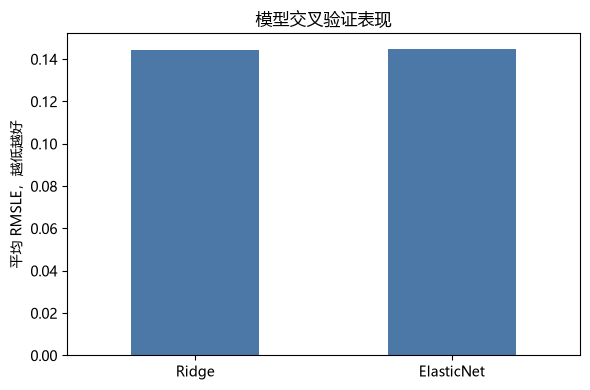

In [9]:
ax = model_scores.plot(kind="bar", x="模型", y="平均 RMSLE", legend=False, figsize=(6, 4), color="#4C78A8")
ax.set_title("模型交叉验证表现")
ax.set_xlabel("")
ax.set_ylabel("平均 RMSLE，越低越好")
plt.xticks(rotation=0)
plt.tight_layout()

## 9. 使用最佳模型生成提交文件

选择交叉验证 RMSLE 更低的模型，用全部训练数据重新训练，然后对测试集预测并生成提交文件。

In [10]:
best_model_name = model_scores.iloc[0]["模型"]
best_model = ridge_model if best_model_name == "Ridge" else elasticnet_model

best_model.fit(X_fe, y)
test_predictions = np.maximum(best_model.predict(X_test_fe), 0)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_predictions})
SUBMISSION_DIR.mkdir(exist_ok=True)
submission_path = SUBMISSION_DIR / "02_submission_cleaning_modeling.csv"
submission.to_csv(submission_path, index=False)

best_model_name, submission_path, submission.head()

('Ridge',
 WindowsPath('C:/Users/84740/house-prices-advanced-regression/submissions/02_submission_cleaning_modeling.csv'),
      Id      SalePrice
 0  1461  115714.317869
 1  1462  151937.820981
 2  1463  171273.718816
 3  1464  195483.455102
 4  1465  196439.886749)

## 10. 后续优化方向

- 更细致地处理异常点，尤其是 `GrLivArea` 很大但售价偏低的样本。
- 对偏态严重的数值特征做 `log1p` 变换。
- 引入 XGBoost、LightGBM 或 CatBoost，并与线性模型做融合。
- 针对有序类别特征使用有序编码，例如质量等级类字段。
- 使用更系统的交叉验证和特征选择来减少过拟合。